## Basics

In [1]:
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 16.59it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20260423"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        text = text.replace('_', ' _')
        wrapped = textwrap.fill(text, width=width, break_long_words=break_long_words)
        labels.append(wrapped)
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc


def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
    return newdf_a
        
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

## Formulas to run


In [5]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling_20260423.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Lin reg of OSAR

In [39]:
mbon_in_aso = ["MB434B", "MB210B", "MB112C", "SS01194", "MB077B", "SS67741"]

In [41]:
df02omitteddf

,MBON,responder,PI_Hg_OSAR,Log2 Speed ratio_Hg_OSAR,Log2 Bout Speed ratio_Hg_OSAR,Light Attraction Index_Hg_OSAR,Bout Number Index_Hg_OSAR,Bout Duration ratio_Hg_OSAR,Max Velocity ratio_Hg_OSAR,Speed ratio_Hg_OSAR,Bout Speed ratio_Hg_OSAR
3,MB434B,Chrimson2,-0.484317,0.363749,-0.602173,-0.361077,-0.341151,-0.184864,-0.067421,0.144010,-0.629100
9,MB077B,Chrimson2,-0.153291,0.103042,0.120246,0.098745,-0.071929,-0.415538,-0.044609,-0.133545,0.321451
13,MB210B,Chrimson2,-0.094999,0.066088,0.179836,-0.100782,-0.087906,0.041808,0.258764,-0.030457,0.202935
25,MB112C,Chrimson2,0.244231,0.186355,0.392273,0.065169,0.171952,0.214931,0.395470,-0.009774,0.442356
27,SS01194,Chrimson2,0.254055,-0.157406,-0.052071,0.297878,-0.148192,0.179373,0.084884,0.233283,0.134897
31,SS67741,Chrimson2,0.542885,-0.435818,0.068477,0.443361,-0.014714,0.023694,-0.045407,-0.222522,0.159221


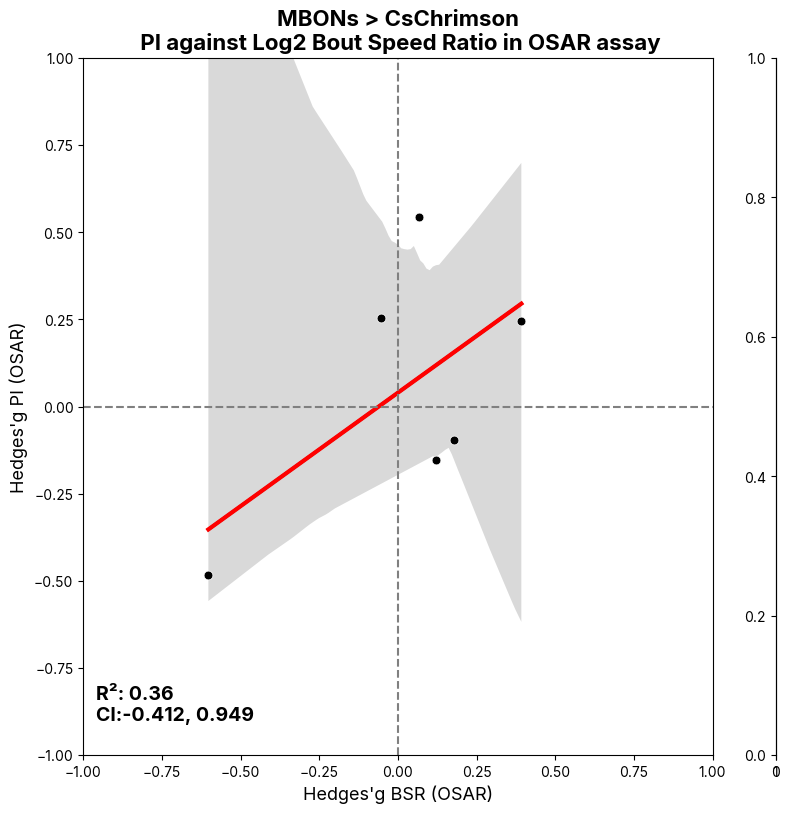

In [47]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = 'Chrimson2'
   
# Read the specific condition file
totalmetriccomparison = pd.read_excel(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full.xlsx")

if  responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    df_specificmbon =df_specificmbon[df_specificmbon['MBON'].isin(mbon_in_aso)]
    colorline = "#ff0000"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    df_specificmbon = df_specificmbon[df_specificmbon['MBON'].isin(mbon_in_aso)]
    colorline = "#14962c"

figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(8, 8), gridspec_kw={"width_ratios":[1,0]})

df02omitteddf = df_specificmbon.copy()
# First subplot
y_label_1 = 'PI_Hg_OSAR'
x_label_1 = 'Log2 Bout Speed ratio_Hg_OSAR'

# df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)
# df02omitteddf = df02omitteddf[~df02omitteddf['MBON'].isin(['VT999036'])]

sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

axscatter_o[0].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
axscatter_o[0].set_xlabel("Hedges'g BSR (OSAR)", fontsize = 13)
axscatter_o[0].grid(False)
axscatter_o[0].set_ylim([-1, 1])
axscatter_o[0].set_xlim([-1, 1])
axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].set_title("MBONs > " + responderrename + "\n PI against Log2 Bout Speed Ratio in OSAR assay", weight = "bold", fontfamily = "Inter", fontsize = 16)
axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

# for n, k in enumerate(df02omitteddf['MBON']):
#     axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

#correlation for first subplot
pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2)

# plt.savefig(filesavedir + date + "_" + responder + "_linreg_in OSAR only.png", dpi = 1200, bbox_inches='tight')
plt.savefig(filesavedir + date + "_" + responder + "_SPeedcomparisons_in OSAR only.svg")

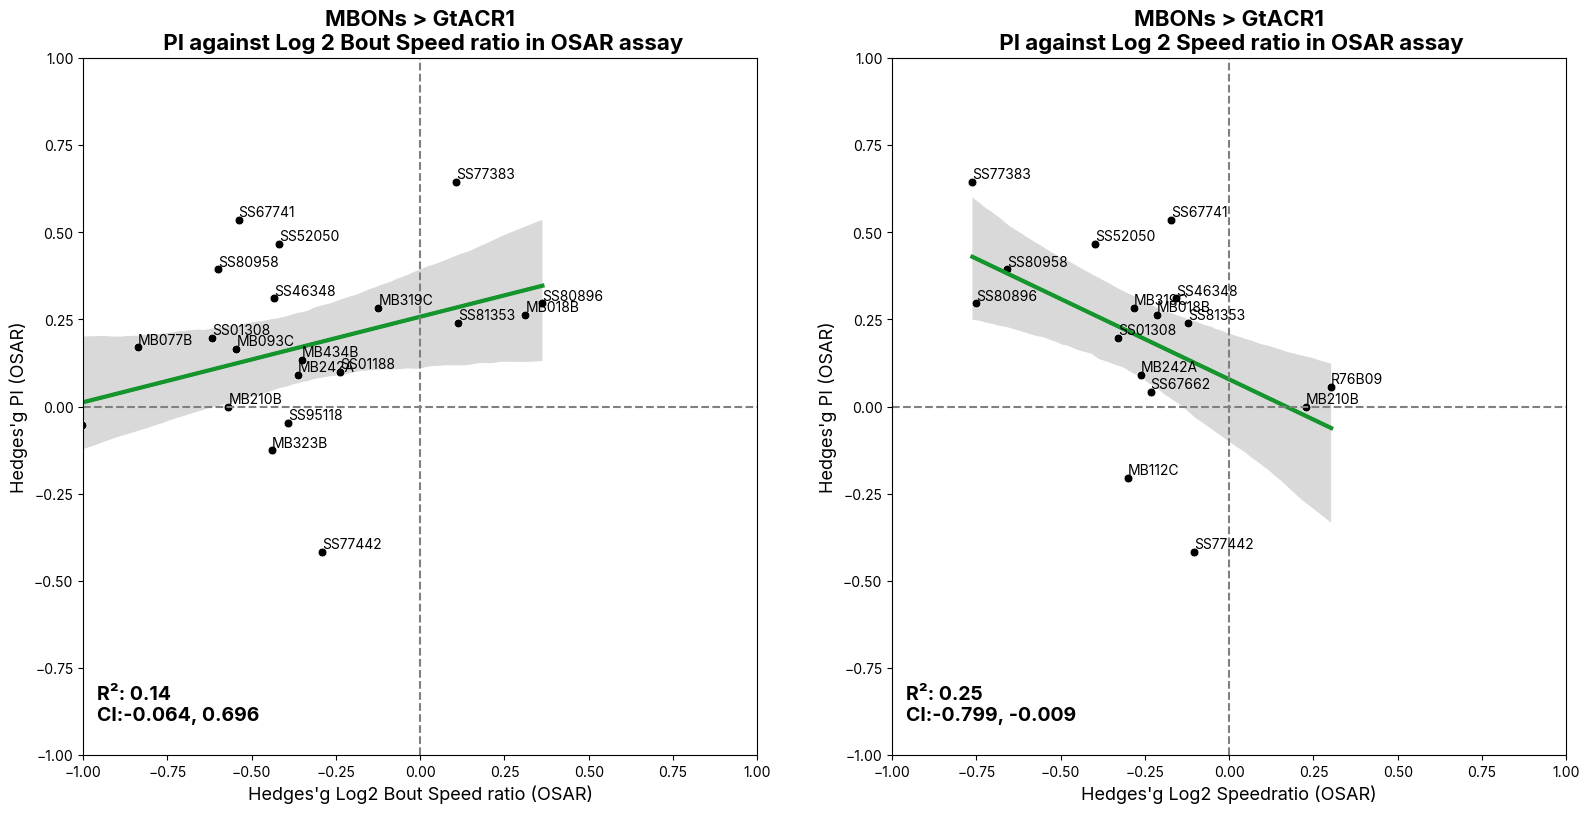

In [ ]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")

    responder = "ACR"

    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = "#ff0000"

    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = "#14962c"

    figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios":[1,1]})

    # First subplot
    y_label_1 = "PI_Δg_OSAR"
    x_label_1 = 'Log2 Bout Speed ratio_Δg_OSAR'

    df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)
    df02omitteddf = df02omitteddf[~df02omitteddf['MBON'].isin(['VT999036'])]

    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
    sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

    axscatter_o[0].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
    axscatter_o[0].set_xlabel("Hedges'g Log2 Bout Speed ratio (OSAR)", fontsize = 13)
    axscatter_o[0].grid(False)
    axscatter_o[0].set_ylim([-1, 1])
    axscatter_o[0].set_xlim([-1, 1])
    axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].set_title("MBONs > " + responderrename + "\n PI against Log 2 Bout Speed ratio in OSAR assay", weight = "bold", fontfamily = "Inter", fontsize = 16)
    axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df02omitteddf['MBON']):
        axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

    #correlation for first subplot
    pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


    # Second subplot
    y_label_2 = "PI_Δg_OSAR"
    x_label_2 = 'Log2 Speed ratio_Δg_OSAR'
    
    df_omitted02_2ndplot = df_specificmbon[~((df_specificmbon[x_label_2].abs() < 0.2) & (df_specificmbon[y_label_2].abs() < 0.2))].reset_index(drop=True)
    df_omitted02_2ndplot = df_omitted02_2ndplot[~df_omitted02_2ndplot['MBON'].isin(['VT999036'])]
    
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
    sns.scatterplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, s = 40, color = 'k', ax=axscatter_o[1])

    axscatter_o[1].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
    axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
    axscatter_o[1].grid(False)
    axscatter_o[1].set_ylim([-1, 1])
    axscatter_o[1].set_xlim([-1, 1])
    axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].set_title("MBONs > " + responderrename + "\n PI against Log 2 Speed ratio in OSAR assay", weight = "bold", fontsize = 16)
    axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_omitted02_2ndplot['MBON']):
        axscatter_o[1].annotate(k, (df_omitted02_2ndplot.loc[n,x_label_2], df_omitted02_2ndplot.loc[n,y_label_2]+0.01), fontsize = 10)

    #correlation for second subplot
    pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df_omitted02_2ndplot[x_label_2], df_omitted02_2ndplot[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

    plt.tight_layout()
    plt.subplots_adjust(top = 0.95, wspace=0.2)

    plt.savefig(filesavedir + date + "_" + responder + "_linreg_ OSAR only.png", dpi = 1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_in OSAR only.svg")

## Lin reg of falling and osar

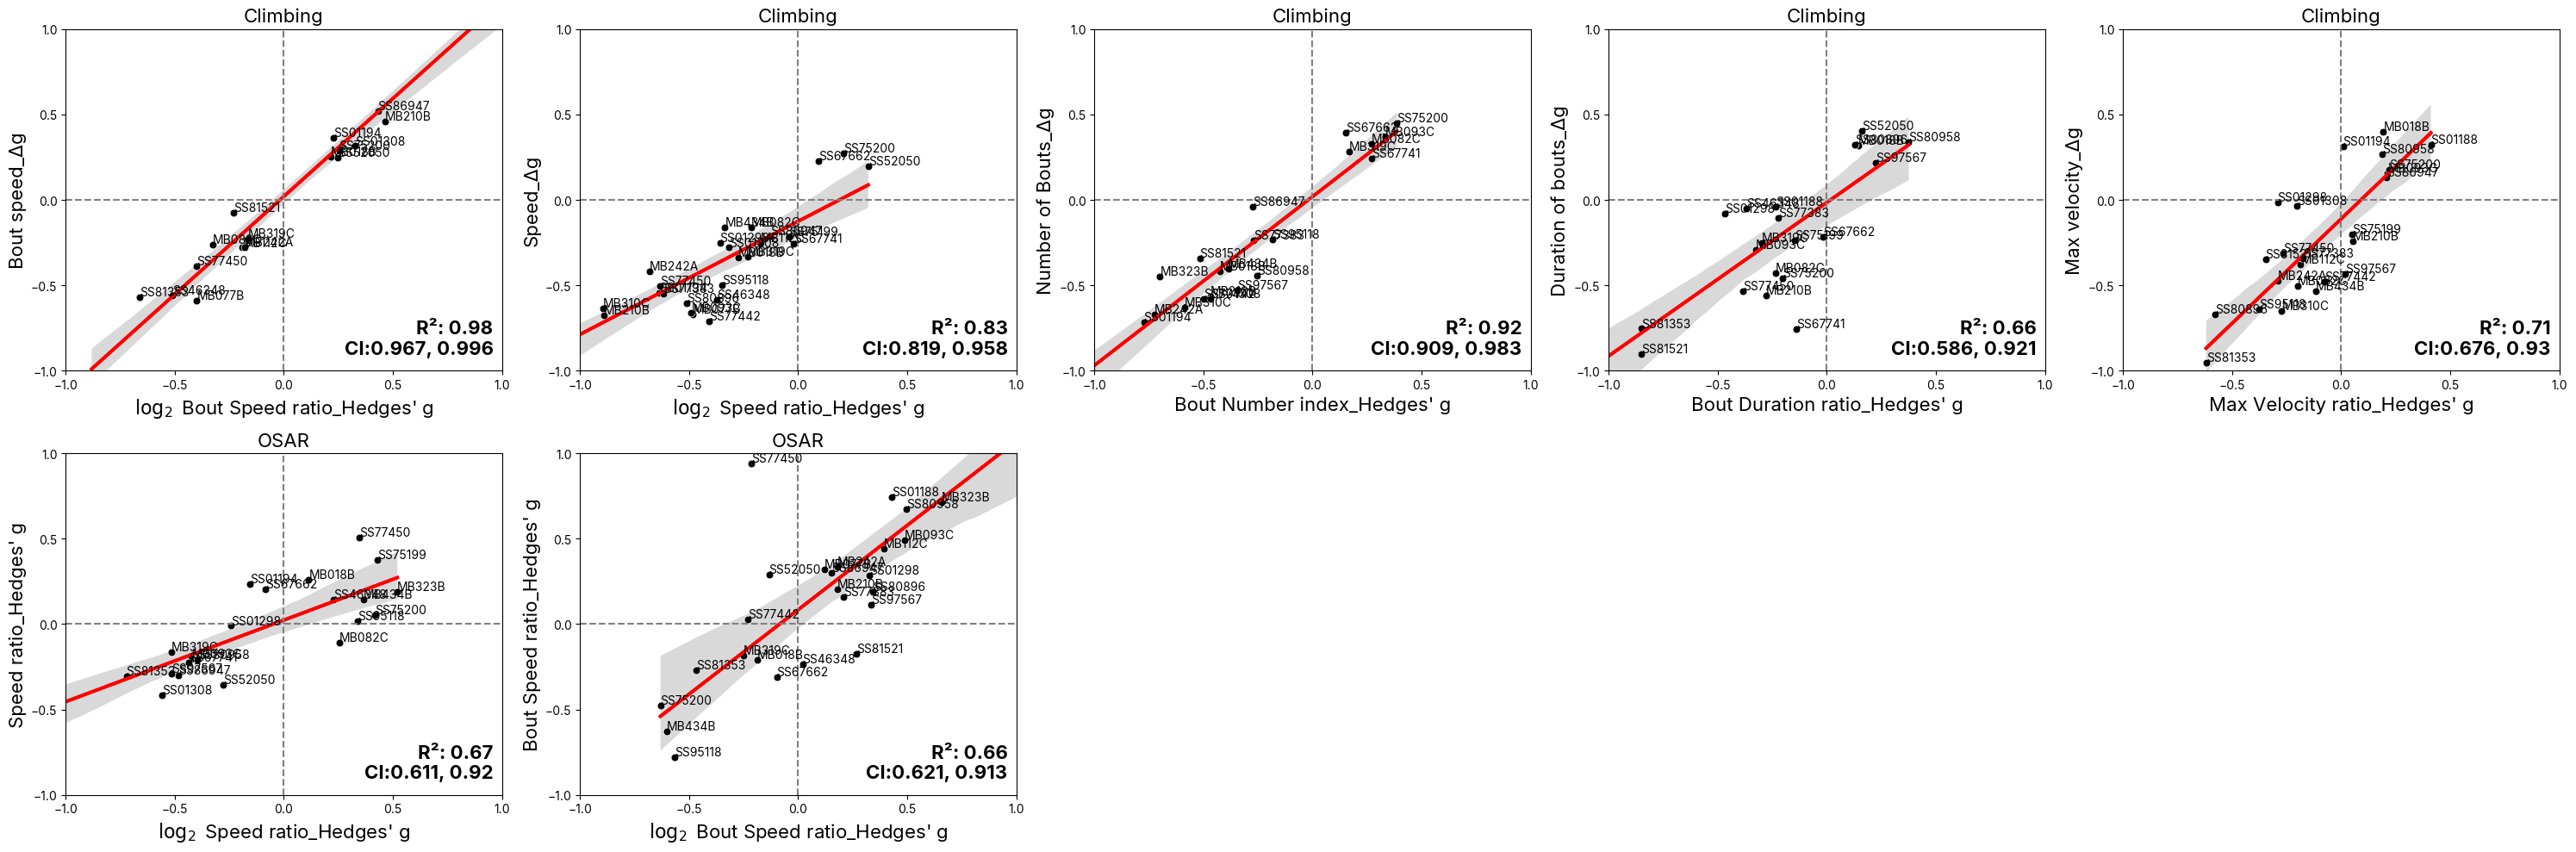

In [6]:
import scipy.stats
plt.rcParams["font.family"] = "Inter"

def clean_label(label):
    for suffix in ['_Δg_Falling', '_Δg_OSAR']:
        label = label.replace(suffix, '_Δg')
    for suffix in ['_Hg_Falling', '_Hg_OSAR']:
        label = label.replace(suffix, "_Hedges' g")
    label = label.replace('Log2', r'$\log_2$')
    return label

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

responder = "Chrimson2"
responderrename = "CsChrimson" if responder == "Chrimson2" else "GtACR1"
colorline = "#ff0000" if responder == "Chrimson2" else "#14962c"

df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder'] == responder].reset_index(drop=True)
df_specificmbon = df_specificmbon[~df_specificmbon['MBON'].isin(['VT999036', 'R76B09', 'R58', 'Th-Gal4'])]

falling_pairs = [
    ('Log2 Bout Speed ratio_Hg_Falling', 'Bout speed_Δg_Falling'),
    ('Log2 Speed ratio_Hg_Falling', 'Speed_Δg_Falling'),
    ('Bout Number index_Hg_Falling', 'Number of Bouts_Δg_Falling'),
    ('Bout Duration ratio_Hg_Falling', 'Duration of bouts_Δg_Falling'),
    ('Max Velocity ratio_Hg_Falling', 'Max velocity_Δg_Falling'),
]

osar_pairs = [
    ('Log2 Speed ratio_Hg_OSAR', 'Speed ratio_Hg_OSAR'),
    ('Log2 Bout Speed ratio_Hg_OSAR', 'Bout Speed ratio_Hg_OSAR'),
]


fig, axes = plt.subplots(2, 5, figsize=(30, 10))
axs = axes.flatten()
all_pairs = falling_pairs + osar_pairs

for idx, (x_col, y_col) in enumerate(all_pairs):
    ax = axs[idx]
    df_plot = df_specificmbon[~((df_specificmbon[x_col].abs() < 0.2) & (df_specificmbon[y_col].abs() < 0.2))].reset_index(drop=True)

    sns.regplot(x=x_col, y=y_col, data=df_plot, ci=95, scatter=False, line_kws={"color": "black"}, ax=ax)
    sns.regplot(x=x_col, y=y_col, data=df_plot, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=ax)
    sns.scatterplot(x=x_col, y=y_col, data=df_plot, s=40, color='k', ax=ax)

    assay = "Climbing" if idx < 5 else "OSAR"
    ax.set_xlabel(clean_label(x_col), fontsize=16)
    ax.set_ylabel(clean_label(y_col), fontsize=16)
    ax.set_title(f"{assay}", fontsize=16)
    ax.grid(False)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.axvline(0, c=(.5, .5, .5), ls='--')
    ax.axhline(0, c=(.5, .5, .5), ls='--')
    ax.yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_plot['MBON']):
        ax.annotate(k, (df_plot.loc[n, x_col], df_plot.loc[n, y_col] + 0.01), fontsize=10)

    r_result = scipy.stats.pearsonr(df_plot[x_col], df_plot[y_col])
    ci_low = r_result.confidence_interval(confidence_level=0.95)[0]
    ci_high = r_result.confidence_interval(confidence_level=0.95)[1]
    ax.annotate(f"R²: {round(r_result[0], 3)**2:.2f}\nCI:{round(ci_low, 3)}, {round(ci_high, 3)}",
                (0.98, 0.05), ha="right", xycoords='axes fraction', weight="bold", fontsize=16)

axs[7].set_visible(False)
axs[8].set_visible(False)
axs[9].set_visible(False)

plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'

#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\linregofmetricsconversion_" + responder +".svg", bbox_inches="tight")
plt.show()

In [8]:
totalmetriccomparison.columns

Index(['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Average height climbed_Δg_Falling', 'Bout speed_Δg_Falling',
       'Pause position_Δg_Falling', 'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 'Log2 Bout Speed ratio_Hg_Falling',
       'Log2 Speed ratio_Hg_Falling', 'Bout Number index_Hg_Falling',
       'Bout Duration ratio_Hg_Falling', 'Max Velocity ratio_Hg_Falling',
       'responder', 'genotypeandresponder', 'MBON', 'PI_Hg_OSAR',
       'Log2 Speed ratio_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
       'Light Attraction Index_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
       'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
       'Speed ratio_Hg_OSAR', 'Bout Speed ratio_Hg_OSAR'],
      dtype='object')

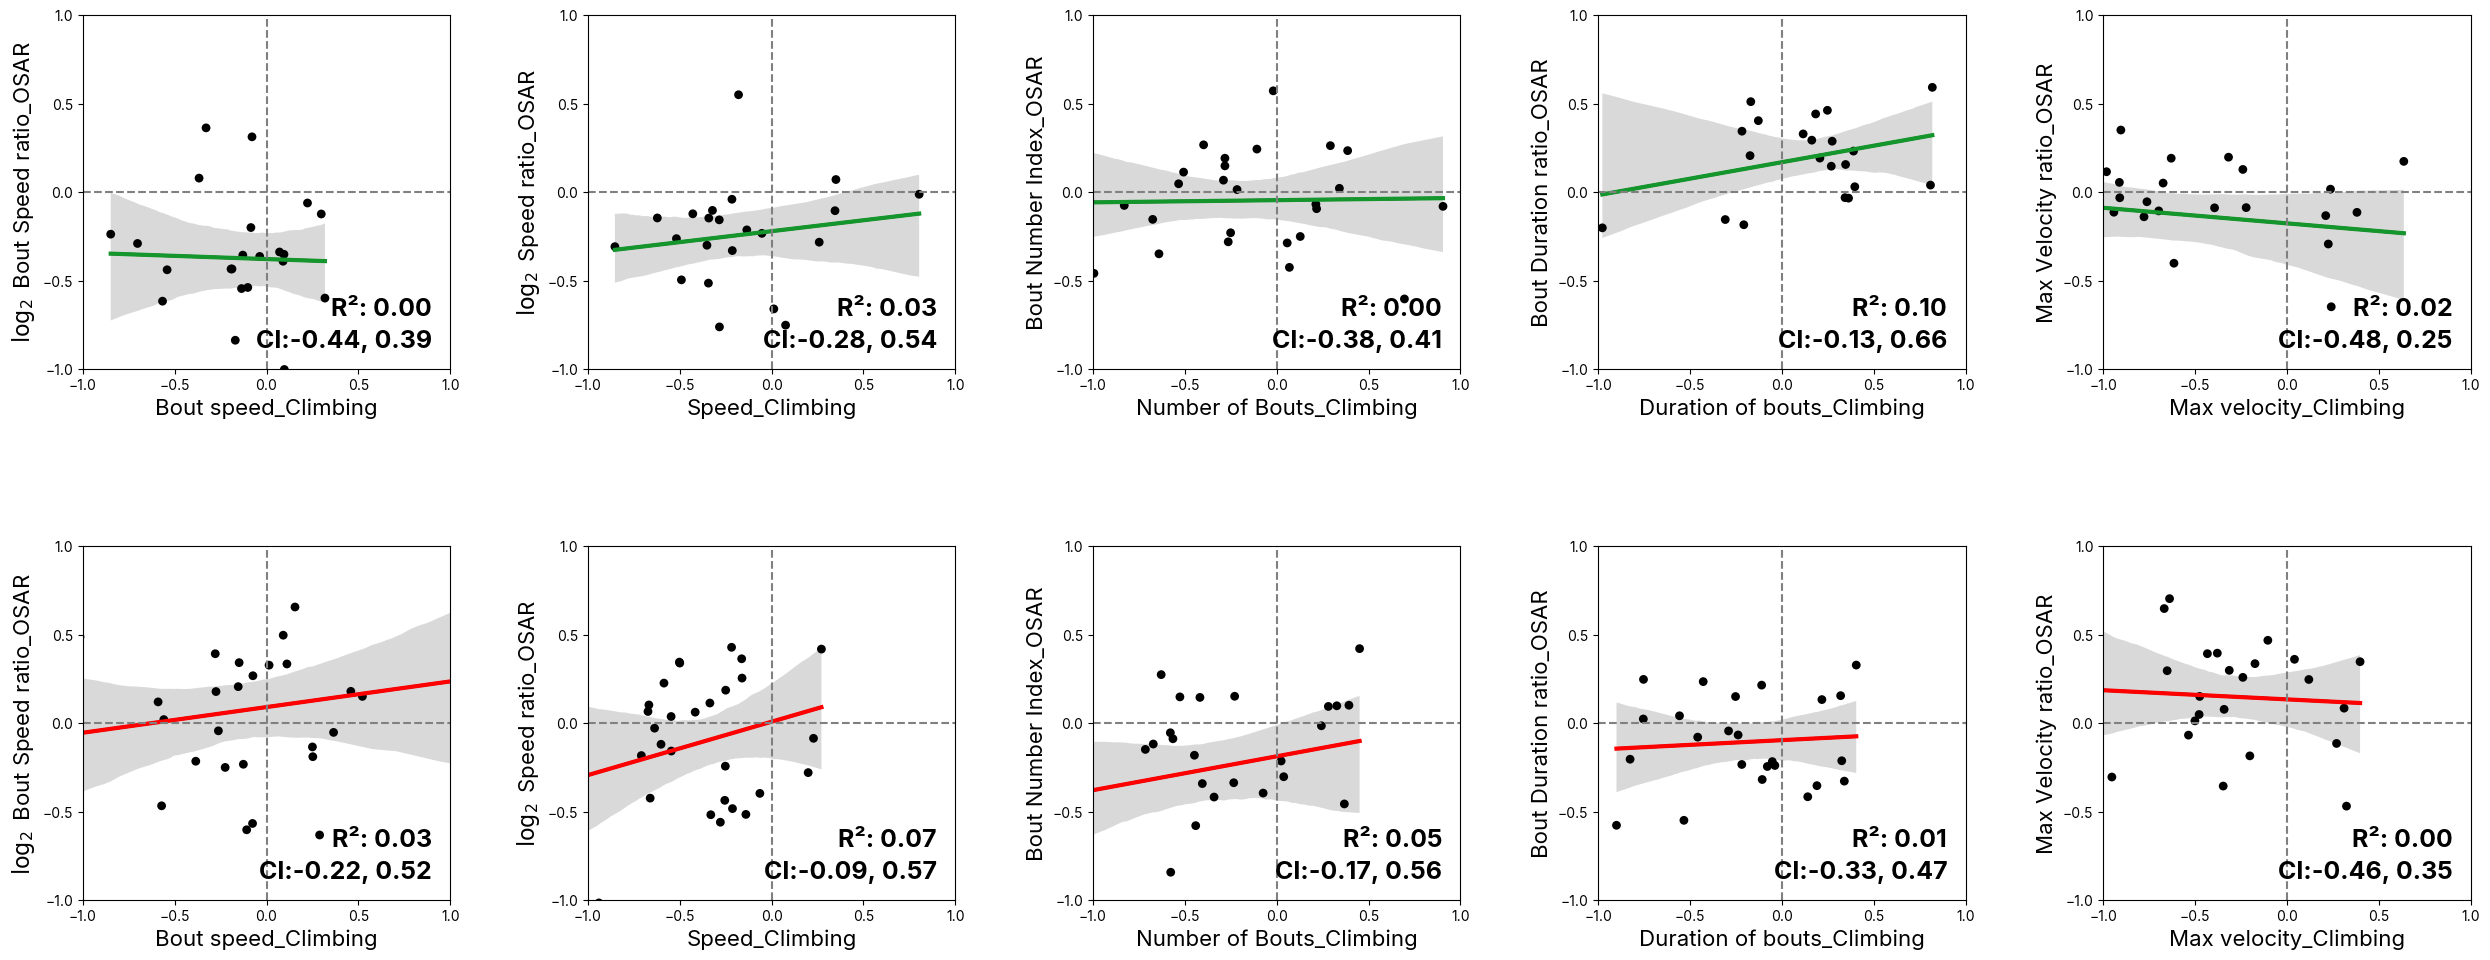

In [17]:
## falling osar metric matching
import scipy.stats
plt.rcParams["font.family"] = "Inter"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

falling_pairs = [
    ('Bout speed_Δg_Falling', 'Log2 Bout Speed ratio_Hg_OSAR'),
    ('Speed_Δg_Falling', 'Log2 Speed ratio_Hg_OSAR'),
    ('Number of Bouts_Δg_Falling', 'Bout Number Index_Hg_OSAR'),
    ('Duration of bouts_Δg_Falling', 'Bout Duration ratio_Hg_OSAR'),
    ('Max velocity_Δg_Falling', 'Max Velocity ratio_Hg_OSAR'),
]

def clean_label(label):
    for suffix in ['_Δg_Falling']:
        label = label.replace(suffix, '_Climbing')
    for suffix in ['_Hg_OSAR']:
        label = label.replace(suffix, "_OSAR")
    label = label.replace('Log2', r'$\log_2$')
    return label

responders = ["ACR", "Chrimson2"]
colorlines = {"ACR": "#14962c", "Chrimson2": "#ff0000"}
respondernames = {"ACR": "GtACR1", "Chrimson2": "CsChrimson"}

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for col, responder in enumerate(responders):
    colorline = colorlines[responder]
    responderrename = respondernames[responder]
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder'] == responder].reset_index(drop=True)
    df_specificmbon = df_specificmbon[~df_specificmbon['MBON'].isin(['VT999036', 'R76B09', 'R58', 'Th-Gal4'])]

    for idx, (x_col, y_col) in enumerate(falling_pairs):
        ax = axes[col, idx]
        df_plot = df_specificmbon[~((df_specificmbon[x_col].abs() < 0.2) & (df_specificmbon[y_col].abs() < 0.2))].reset_index(drop=True)

        sns.regplot(x=x_col, y=y_col, data=df_plot, ci=95, scatter=False, line_kws={"color": "black"}, ax=ax)
        sns.regplot(x=x_col, y=y_col, data=df_plot, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=ax)
        sns.scatterplot(x=x_col, y=y_col, data=df_plot, s=40, color='k', edgecolors='none', ax=ax)

        ax.set_xlabel(clean_label(x_col), fontsize=16)
        ax.set_ylabel(clean_label(y_col), fontsize=16)
        #ax.set_title(f"{clean_label(x_col)} \nvs {clean_label(y_col)}", fontsize=16)
        ax.grid(False)
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.axvline(0, c=(.5, .5, .5), ls='--')
        ax.axhline(0, c=(.5, .5, .5), ls='--')
        ax.yaxis.set_tick_params(labelbottom=True)

        r_result = scipy.stats.pearsonr(df_plot[x_col], df_plot[y_col])
        ci_low = r_result.confidence_interval(confidence_level=0.95)[0]
        ci_high = r_result.confidence_interval(confidence_level=0.95)[1]
        ax.annotate(f"R²: {round(r_result[0], 2)**2:.2f}\nCI:{round(ci_low, 2)}, {round(ci_high, 2)}", 
                    (0.95, 0.06), ha="right", xycoords='axes fraction', linespacing=1.5, weight="bold", fontsize=18)

plt.tight_layout(w_pad=4)
plt.subplots_adjust(top=0.95, hspace=0.5)
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\assayconversion.svg", bbox_inches="tight")

plt.show()

## Bazhang linreg

In [8]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

In [10]:
totalmetriccomparison.columns

no_corrmetrics = ['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Average height climbed_Δg_Falling', 'Bout speed_Δg_Falling',
       'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 'PI_Hg_OSAR',
       'Log2 Speed ratio_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
       'Light Attraction Index_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
       'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR']

corrmetrics_fallingonly = ['Log2 Bout Speed ratio_Hg_Falling','Bout speed_Δg_Falling',
       'Log2 Speed ratio_Hg_Falling', 'Speed_Δg_Falling',
       'Bout Number index_Hg_Falling', 'Number of Bouts_Δg_Falling',
       'Bout Duration ratio_Hg_Falling', 'Duration of bouts_Δg_Falling',
       'Max Velocity ratio_Hg_Falling','Max velocity_Δg_Falling'
        ]

corrmetricswithosar = ['Log2 Bout Speed ratio_Hg_Falling',
       'Log2 Speed ratio_Hg_Falling', 'Bout Number index_Hg_Falling',
       'Bout Duration ratio_Hg_Falling', 'Max Velocity ratio_Hg_Falling',
       'Log2 Speed ratio_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
       'Light Attraction Index_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
       'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR']

nologcorr = ['Log2 Speed ratio_Hg_OSAR', 'Speed ratio_Hg_OSAR',
             'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Speed ratio_Hg_OSAR' ]

In [11]:
responder = "Chrimson2"
mode = "all"  #single, multi, or all

extras = ['responder', 'MBON']

metrics_to_compute = extras + corrmetricswithosar


specificmetricdf = totalmetriccomparison[metrics_to_compute]


if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="Chrimson2"].reset_index(drop=True)
    cmapcolor = "Reds"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="ACR"].reset_index(drop=True)
    cmapcolor = "Greens"

df_specificmbon = df_specificmbon[~df_specificmbon['MBON'].isin(['R76B09', 'VT999036'])]
df_nta = df_specificmbon.drop(columns = ['responder'])
df_allmbons = df_nta.set_index('MBON')

datasettouse = df_allmbons
modename = "Single and Multi-celled"


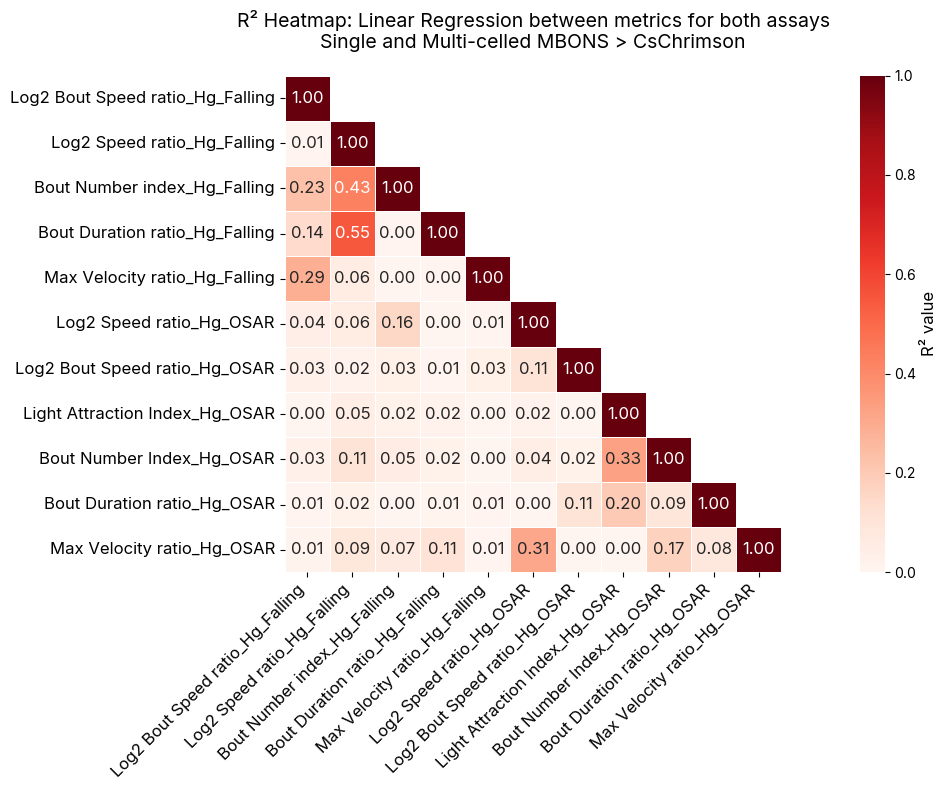

In [12]:
from scipy.stats import linregress

datasettouse.columns = datasettouse.columns.str.replace("_Δg", "", regex=False)
df_linreg = datasettouse.copy()
n_metrics = len(df_linreg.columns)
r2_matrix = np.zeros((n_metrics, n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        
        # Filter out MBONs where BOTH x and y are less than 0.2 in absolute value
        valid_mask = ~((x.abs() < 0.2) & (y.abs() < 0.2))
        x_filtered = x[valid_mask]
        y_filtered = y[valid_mask]
        
        # Only calculate regression if we have enough data points
        if len(x_filtered) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)
            r2_matrix[i, j] = r_value**2
        else:
            r2_matrix[i, j] = np.nan  # Not enough data
        
r2_df = pd.DataFrame(r2_matrix, 
                     columns=df_linreg.columns, 
                     index=df_linreg.columns)

mask = np.triu(np.ones_like(r2_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 8))
hmap = sns.heatmap(r2_df, annot=True, fmt='.2f', cmap=cmapcolor, 
            vmin=0, vmax=1, center=0.5, annot_kws={'fontsize': 12},
            cbar_kws={'label': 'R² value'},
            square=True, linewidths=0.5, ax=ax,
            mask=mask)  

cbar = hmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('R² value', fontsize=12)

plt.title(f"R² Heatmap: Linear Regression between metrics for both assays\n" + modename + " MBONS > " + responderrename, 
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha = "right", fontsize = 12)
# wrap_labels(hmap, 5)
plt.yticks(rotation=0, fontsize = 12)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'


#plt.savefig(filesavedir + date + "_" + responder + "_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\" + date + "_" + responder + "_Falling_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
plt.show()

## Comparison of PI against all types

In [13]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


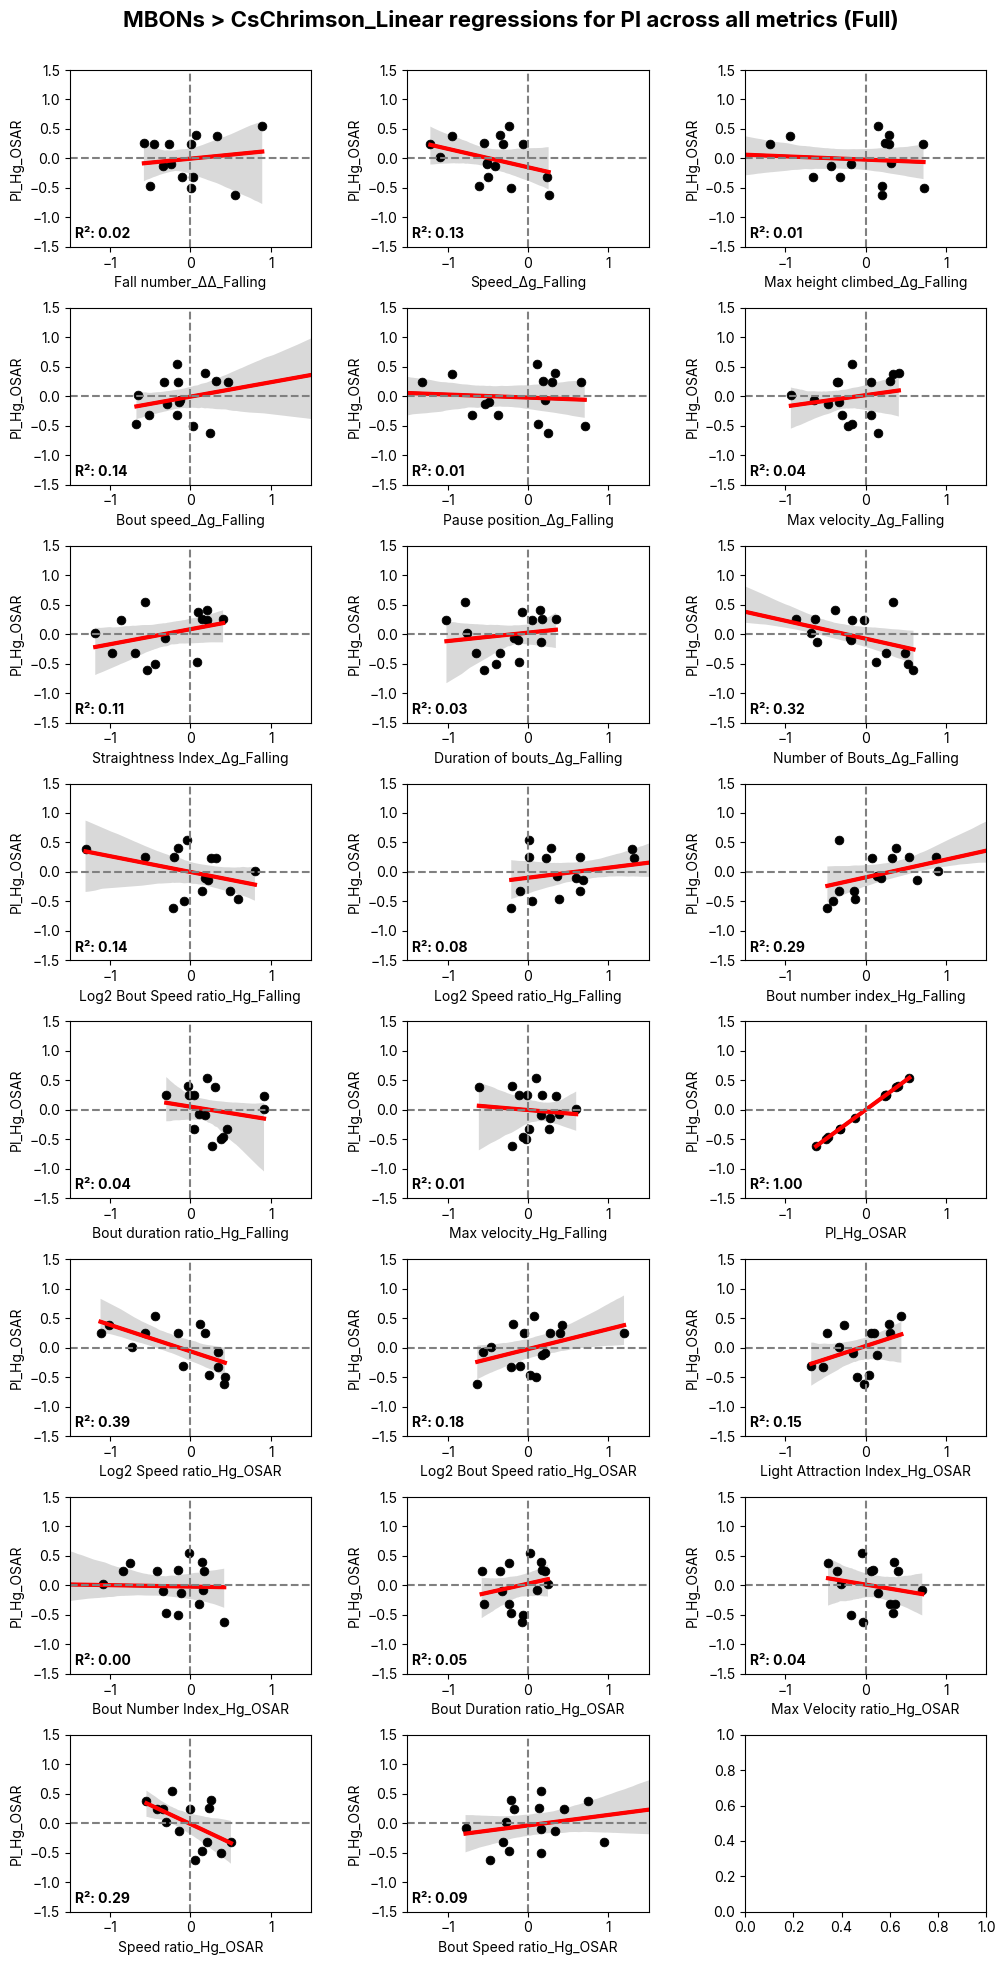

Generated plot for Full condition


In [14]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = 'red'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = 'green'
    
    totalmapplots = df_linereg.drop(columns = ['genotypeandresponder', 'responder'])
    df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(singlecellmbon)]
    
    df_totalmetrics = df_totalmetrics_origin.drop(columns = ['MBON'])
    metrictype = df_totalmetrics.columns.tolist()
        
    figlinregplots, axes = plt.subplots(8,3, figsize=(10,20))
    axscatter_linreg = axes.flatten()
       
    for k,j in zip(metrictype, range(len(metrictype))):
  
        x_label_1 = k 
        y_label_1 = 'PI_Hg_OSAR'    

        data_nt = df_totalmetrics_origin[~((df_totalmetrics_origin[x_label_1].abs() < 0.1) & (df_totalmetrics_origin[y_label_1].abs() < 0.2))].reset_index(drop=True)
        
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_linreg[j])
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_linreg[j])
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color= "black", edgecolors="face", ax=axscatter_linreg[j])

        axscatter_linreg[j].grid(False)
        axscatter_linreg[j].set_ylim([-1.5, 1.5])
        axscatter_linreg[j].set_xlim([-1.5, 1.5])
        axscatter_linreg[j].axvline(0, c=(.5, .5, .5), ls='--')
        axscatter_linreg[j].axhline(0, c=(.5, .5, .5), ls='--')
        
        axscatter_linreg[j].yaxis.set_tick_params(labelbottom=True)

        # Correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
        # civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        # civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        # axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
        #                         (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
        axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}", 
                                (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=10)
    
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.4)
    
    figlinregplots.suptitle(f"MBONs > {responderrename}_Linear regressions for PI across all metrics ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    #plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".png", dpi=1200, bbox_inches='tight')
    #plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

## Neurotransmitter types

In [7]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

KeyError: 'PI_Δg_OSAR'

## HEATMAP of linereg

In [6]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling_20260423.xlsx")

In [33]:
singlecellmbon = ['MB018B','MB080C','MB085C','MB091C','MB112C','MB242A',
'MB262B','MB298B','MB399B','MB622B','SS01127','SS01143',
'SS01188','SS01194','SS01308','SS01337','SS01388','SS46348',
'SS67662','SS67727','SS67728','SS67741','SS67755','SS75199',
'SS75200','SS76094','SS77383','SS77424','SS77450','SS80974',
'SS81353','SS81521','SS95118','SS97567']


In [9]:
responder = "ACR"
mode = "all"  #single, multi, or all

extras = ['responder', 'MBON']
exclude = "Pause position_Δg"
metrics_to_compute = [c for c in totalmetriccomparison.columns.tolist() if ("Δ" in c and c not in exclude) or c in extras]


specificmetricdf = totalmetriccomparison[metrics_to_compute]


if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="Chrimson2"].reset_index(drop=True)
    cmapcolor = "Reds"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="ACR"].reset_index(drop=True)
    cmapcolor = "Greens"

df_specificmbon = df_specificmbon[~df_specificmbon['MBON'].isin(['R76B09', 'VT999036'])]
df_nta = df_specificmbon.drop(columns = ['responder'])
df_allmbons = df_nta.set_index('MBON')

datasettouse = df_allmbons
modename = "Single and Multi-celled"


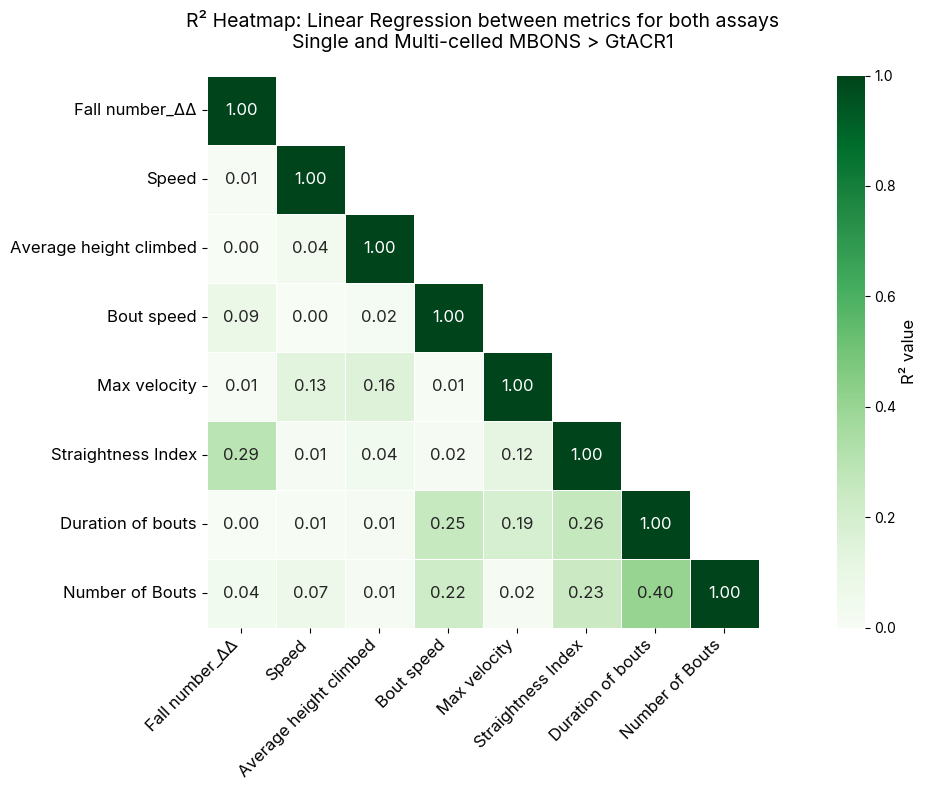

In [10]:
from scipy.stats import linregress

datasettouse.columns = datasettouse.columns.str.replace("_Δg", "", regex=False)
df_linreg = datasettouse.copy()
n_metrics = len(df_linreg.columns)
r2_matrix = np.zeros((n_metrics, n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        
        # Filter out MBONs where BOTH x and y are less than 0.2 in absolute value
        valid_mask = ~((x.abs() < 0.2) & (y.abs() < 0.2))
        x_filtered = x[valid_mask]
        y_filtered = y[valid_mask]
        
        # Only calculate regression if we have enough data points
        if len(x_filtered) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)
            r2_matrix[i, j] = r_value**2
        else:
            r2_matrix[i, j] = np.nan  # Not enough data
        
r2_df = pd.DataFrame(r2_matrix, 
                     columns=df_linreg.columns, 
                     index=df_linreg.columns)

mask = np.triu(np.ones_like(r2_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 8))
hmap = sns.heatmap(r2_df, annot=True, fmt='.2f', cmap=cmapcolor, 
            vmin=0, vmax=1, center=0.5, annot_kws={'fontsize': 12},
            cbar_kws={'label': 'R² value'},
            square=True, linewidths=0.5, ax=ax,
            mask=mask)  

cbar = hmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('R² value', fontsize=12)

plt.title(f"R² Heatmap: Linear Regression between metrics for both assays\n" + modename + " MBONS > " + responderrename, 
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha = "right", fontsize = 12)
# wrap_labels(hmap, 5)
plt.yticks(rotation=0, fontsize = 12)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'


#plt.savefig(filesavedir + date + "_" + responder + "_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\" + date + "_" + responder + "_Falling_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
plt.show()

## Heatmap bazhang osar

In [6]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full_20260423.xlsx")

In [9]:
responder = "ACR"
mode = "all"  #single, multi, or all

extras = ['responder', 'MBON']
exclude = ['Bout Speed ratio_Hg_OSAR', 'Speed ratio_Hg_OSAR']
metrics_to_compute = [c for c in totalmetriccomparison.columns.tolist() if (c.endswith('OSAR') and c not in exclude) or c in extras]

# exclude = "Pause position_Δg"
# metrics_to_compute = [c for c in totalmetriccomparison.columns.tolist() if ("Δ" in c and c not in exclude) or c in extras]


specificmetricdf = totalmetriccomparison[metrics_to_compute]


if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="Chrimson2"].reset_index(drop=True)
    cmapcolor = "Reds"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = specificmetricdf[specificmetricdf['responder']=="ACR"].reset_index(drop=True)
    cmapcolor = "Greens"

df_specificmbon = df_specificmbon[~df_specificmbon['MBON'].isin(['R76B09', 'VT999036'])]
df_nta = df_specificmbon.drop(columns = ['responder'])
df_allmbons = df_nta.set_index('MBON')

datasettouse = df_allmbons
modename = "Single and Multi-celled"


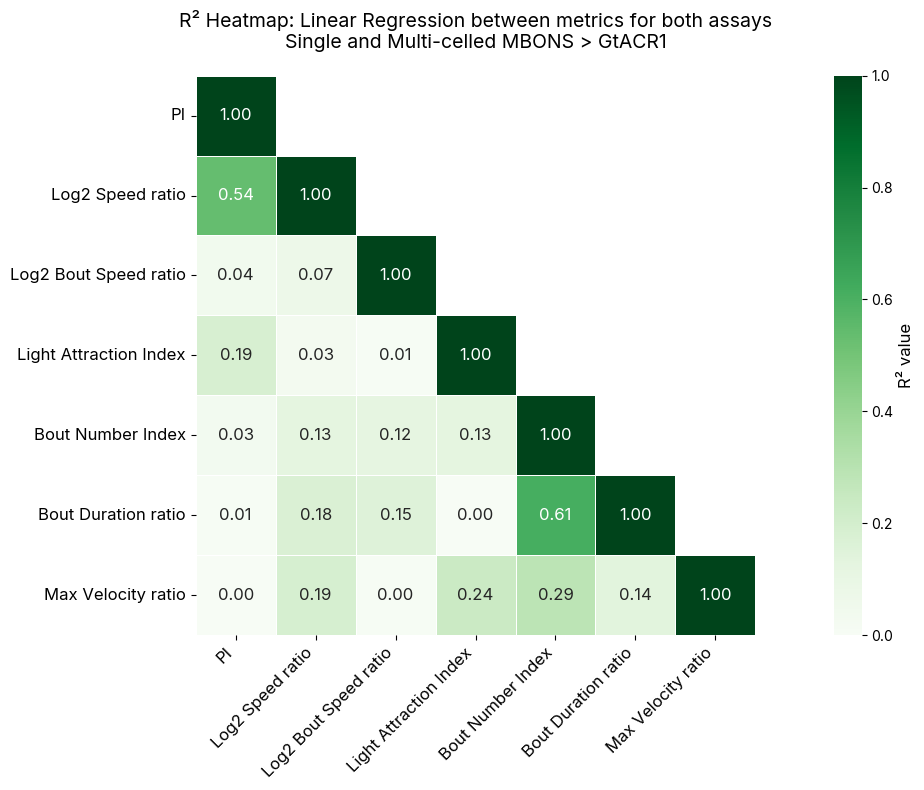

In [10]:
from scipy.stats import linregress

datasettouse.columns = datasettouse.columns.str.replace("_Hg_OSAR", "", regex=False)
df_linreg = datasettouse.copy()
n_metrics = len(df_linreg.columns)
r2_matrix = np.zeros((n_metrics, n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        
        # Filter out MBONs where BOTH x and y are less than 0.2 in absolute value
        valid_mask = ~((x.abs() < 0.2) & (y.abs() < 0.2))
        x_filtered = x[valid_mask]
        y_filtered = y[valid_mask]
        
        # Only calculate regression if we have enough data points
        if len(x_filtered) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x_filtered, y_filtered)
            r2_matrix[i, j] = r_value**2
        else:
            r2_matrix[i, j] = np.nan  # Not enough data
        
r2_df = pd.DataFrame(r2_matrix, 
                     columns=df_linreg.columns, 
                     index=df_linreg.columns)

mask = np.triu(np.ones_like(r2_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 8))
hmap = sns.heatmap(r2_df, annot=True, fmt='.2f', cmap=cmapcolor, 
            vmin=0, vmax=1, center=0.5, annot_kws={'fontsize': 12},
            cbar_kws={'label': 'R² value'},
            square=True, linewidths=0.5, ax=ax,
            mask=mask)  

cbar = hmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('R² value', fontsize=12)

plt.title(f"R² Heatmap: Linear Regression between metrics for both assays\n" + modename + " MBONS > " + responderrename, 
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha = "right", fontsize = 12)
# wrap_labels(hmap, 5)
plt.yticks(rotation=0, fontsize = 12)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'


#plt.savefig(filesavedir + date + "_" + responder + "_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_" + responder + "_heatmaplinregfor_" + modename +".svg", bbox_inches="tight")
plt.show()

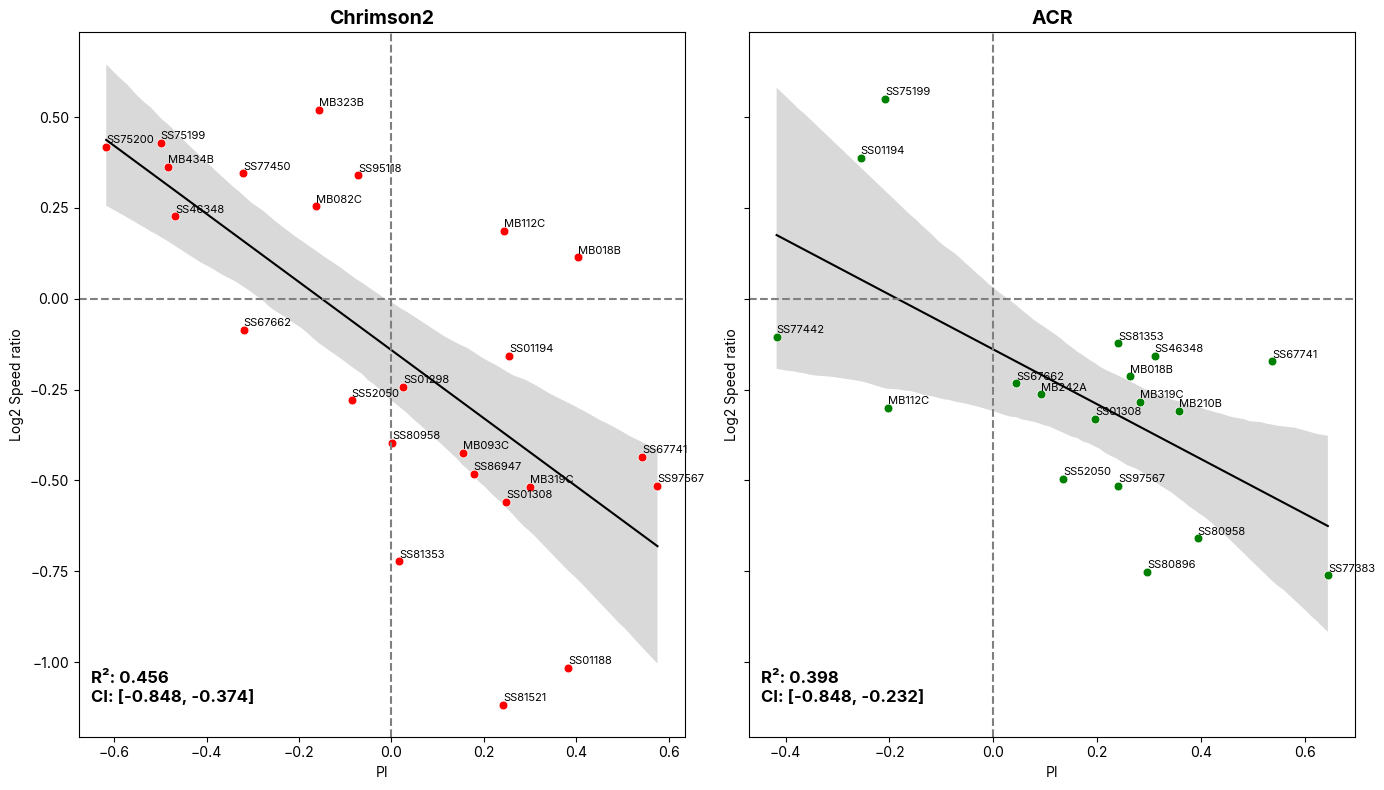

In [12]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

metric_one = "PI"
metric_two = "Log2 Speed ratio"
omission_threshold = 0.2

extras = ['responder', 'MBON']
exclude = ['Bout Speed ratio_Hg_OSAR', 'Speed ratio_Hg_OSAR']
metrics_to_compute = [c for c in totalmetriccomparison.columns.tolist() if (c.endswith('OSAR') and c not in exclude) or c in extras]
specificmetricdf = totalmetriccomparison[metrics_to_compute]

figosarplot, axscatter_o = plt.subplots(1,2, figsize=(14,8), sharey='row')

for idx, (responder, color, ax) in enumerate([("Chrimson2", "red", axscatter_o[0]), ("ACR", "green", axscatter_o[1])]):
    df_resp = specificmetricdf[specificmetricdf['responder'] == responder].reset_index(drop=True)
    df_resp = df_resp[~df_resp['MBON'].isin(['R76B09', 'VT999036', 'R58', 'Th-Gal4'])]
    df_resp = df_resp.drop(columns=['responder'])
    df_resp.columns = df_resp.columns.str.replace("_Hg_OSAR", "", regex=False)
    
    df_clean = df_resp[[metric_one, metric_two, 'MBON']].dropna()
    df_clean = df_clean[~((df_clean[metric_one].abs() < omission_threshold) & (df_clean[metric_two].abs() < omission_threshold))]
    df_clean = df_clean.reset_index(drop=True)
    
    sns.regplot(x=metric_one, y=metric_two, data=df_clean, ci=95, scatter=False, line_kws={"color": "black", 'lw': 1.5}, ax=ax)
    sns.scatterplot(x=metric_one, y=metric_two, data=df_clean, s=40, color=color, ax=ax)
    
    pearson_result = scipy.stats.pearsonr(df_clean[metric_one], df_clean[metric_two])
    r2 = pearson_result[0] ** 2
    ci_low = pearson_result.confidence_interval(confidence_level=0.95)[0]
    ci_high = pearson_result.confidence_interval(confidence_level=0.95)[1]
    
    ax.annotate(f"R²: {r2:.3f}\nCI: [{ci_low:.3f}, {ci_high:.3f}]", 
                (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=12)
    
    ax.axvline(0, c=(.5, .5, .5), ls='--')
    ax.axhline(0, c=(.5, .5, .5), ls='--')
    ax.set_xlabel(metric_one)
    ax.set_ylabel(metric_two)
    ax.set_title(responder, weight="bold", fontsize=14)
    
    for n, row in df_clean.iterrows():
        ax.annotate(row['MBON'], (row[metric_one], row[metric_two] + 0.01), fontsize=8)

plt.tight_layout()
plt.show()